<a href="https://colab.research.google.com/github/holly0923p-stack/IntelligentData_TextAnalytics/blob/main/Coursework_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sbn

# Data Loading and attributes

In [ ]:
depression = pd.read_csv('Depression Professional Dataset.csv')

In [ ]:
depression.head(15)

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,37,2,4,7-8 hours,Moderate,No,6,2,No,No
1,Male,60,4,3,5-6 hours,Unhealthy,Yes,0,4,Yes,No
2,Female,42,2,3,5-6 hours,Moderate,No,0,2,No,No
3,Female,44,3,5,7-8 hours,Healthy,Yes,1,2,Yes,No
4,Male,48,4,3,7-8 hours,Moderate,Yes,6,5,Yes,No
5,Female,60,1,4,7-8 hours,Unhealthy,Yes,12,3,Yes,No
6,Female,30,4,2,More than 8 hours,Healthy,No,3,1,No,No
7,Male,30,1,2,More than 8 hours,Unhealthy,Yes,6,1,No,No
8,Male,56,1,2,More than 8 hours,Moderate,Yes,11,5,Yes,No
9,Female,35,3,4,Less than 5 hours,Moderate,No,6,4,Yes,No


In [ ]:
depression.isnull().sum()

,0
Gender,0
Age,0
Work Pressure,0
Job Satisfaction,0
Sleep Duration,0
Dietary Habits,0
Have you ever had suicidal thoughts ?,0
Work Hours,0
Financial Stress,0
Family History of Mental Illness,0


In [ ]:
depression.describe()

,Age,Work Pressure,Job Satisfaction,Work Hours,Financial Stress
count,2054.000000,2054.000000,2054.000000,2054.000000,2054.000000
mean,42.171860,3.021908,3.015093,5.930867,2.978578
std,11.461202,1.417312,1.418432,3.773945,1.413362
min,18.000000,1.000000,1.000000,0.000000,1.000000
25%,35.000000,2.000000,2.000000,3.000000,2.000000
50%,43.000000,3.000000,3.000000,6.000000,3.000000
75%,51.750000,4.000000,4.000000,9.000000,4.000000
max,60.000000,5.000000,5.000000,12.000000,5.000000


In [ ]:
depression.shape

(2054, 11)

In [ ]:
gender_percentages = depression['Gender'].value_counts(normalize=True) * 100
print(gender_percentages)

Gender
Male      51.898734
Female    48.101266
Name: proportion, dtype: float64


In [ ]:
SuicidalThoughts_percentages = depression['Have you ever had suicidal thoughts ?'].value_counts(normalize=True) * 100
print(SuicidalThoughts_percentages)

Have you ever had suicidal thoughts ?
No     51.850049
Yes    48.149951
Name: proportion, dtype: float64


In [ ]:
Family_History = depression['Family History of Mental Illness'].value_counts(normalize=True) * 100
print(Family_History)

Family History of Mental Illness
No     50.925024
Yes    49.074976
Name: proportion, dtype: float64


# Data Visualisation

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

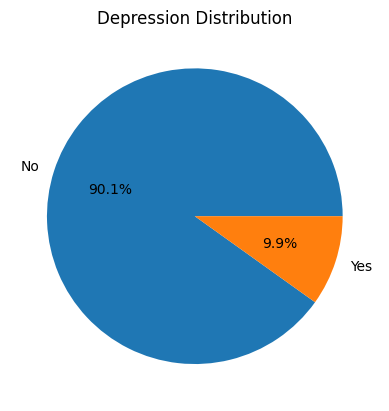

In [ ]:
depression['Depression'].value_counts().plot(kind ='pie', autopct='%1.1f%%')
plt.title('Depression Distribution')
plt.ylabel('')
plt.show()

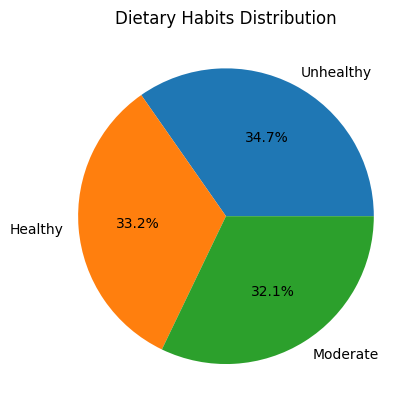

In [ ]:
depression['Dietary Habits'].value_counts().plot(kind ='pie', autopct='%1.1f%%')
plt.title('Dietary Habits Distribution')
plt.ylabel('')
plt.show()

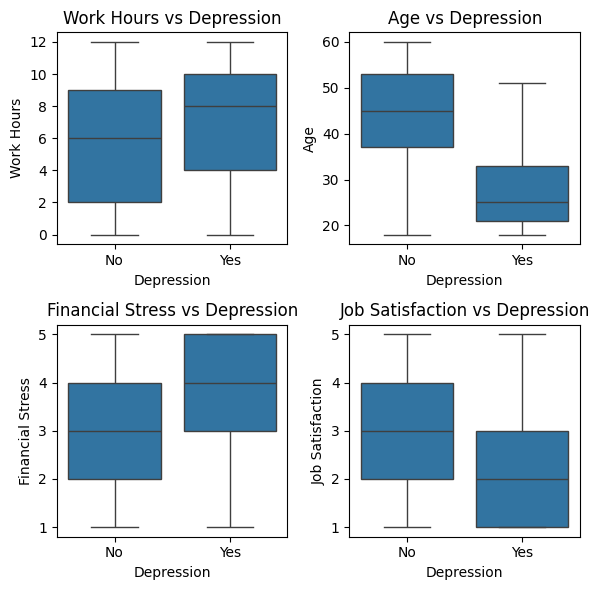

In [ ]:
#using all numerical data generating 4 boxplots

fig, axes = plt.subplots(2, 2, figsize=(6, 6))

sns.boxplot(data=depression, x='Depression', y='Work Hours', ax=axes[0,0])
axes[0,0].set_title('Work Hours vs Depression')

sns.boxplot(data=depression, x='Depression', y='Age', ax=axes[0,1])
axes[0,1].set_title('Age vs Depression')

sns.boxplot(data=depression, x='Depression', y='Financial Stress', ax=axes[1,0])
axes[1,0].set_title('Financial Stress vs Depression')

  sns.boxplot(data=depression, x='Depression', y='Job Satisfaction', ax=axes[1,1])
  axes[1,1].set_title('Job Satisfaction vs Depression')
x
  plt.tight_layout()
  plt.show()

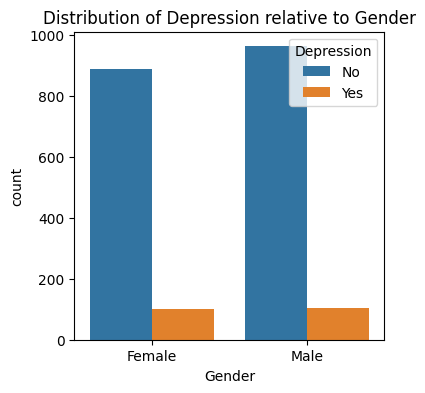

In [ ]:
#Gender disparity suffering with depression

plt.figure(figsize=(4,4))

sns.countplot(data=depression, x='Gender', hue='Depression')
plt.title("Distribution of Depression relative to Gender")
plt.show()

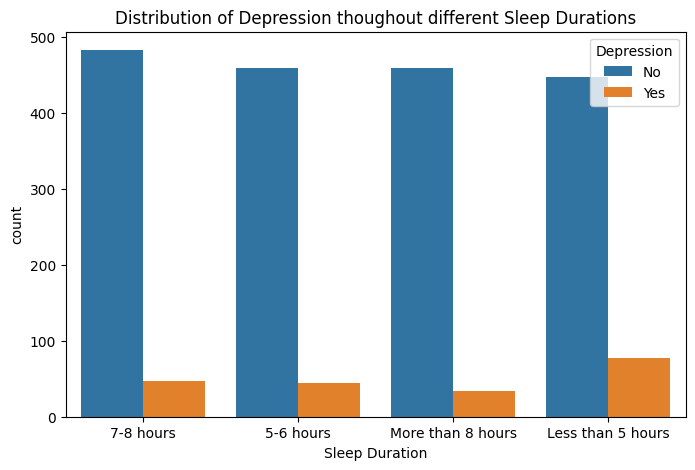

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=depression, x='Sleep Duration', hue='Depression')
plt.title("Distribution of Depression thoughout different Sleep Durations")
plt.show()

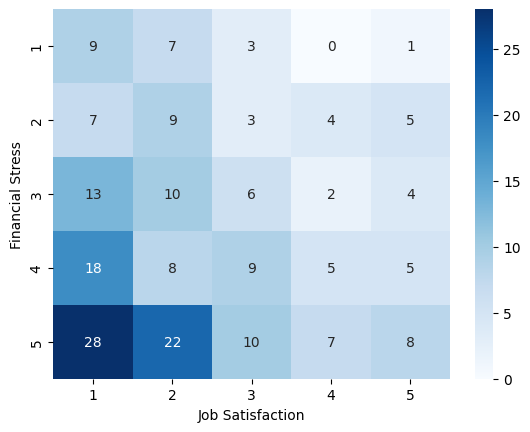

In [ ]:
# heatmap showing correlation between financial stress and Job satisfaction

crosstab = pd.crosstab(
    depression[depression['Depression'] == 'Yes']['Financial Stress'],
    depression[depression['Depression'] == 'Yes']['Job Satisfaction']
)

sns.heatmap(crosstab, annot=True, cmap='Blues', fmt='g')
plt.show()

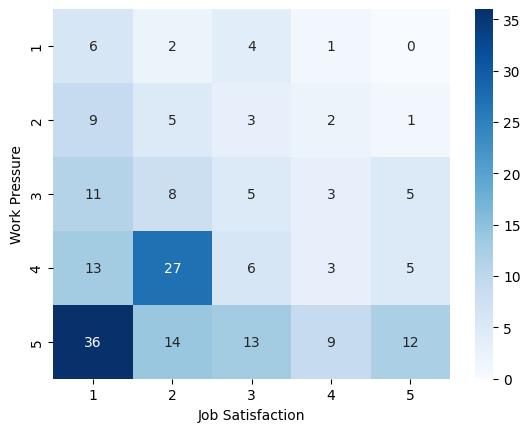

In [ ]:
# heatmap showing correlations between work pressure and Job

crosstab2 = pd.crosstab(
    depression[depression['Depression'] == 'Yes']['Work Pressure'],
    depression[depression['Depression'] == 'Yes']['Job Satisfaction']
)

sns.heatmap(crosstab2, annot=True, cmap='Blues', fmt='g')
plt.show()

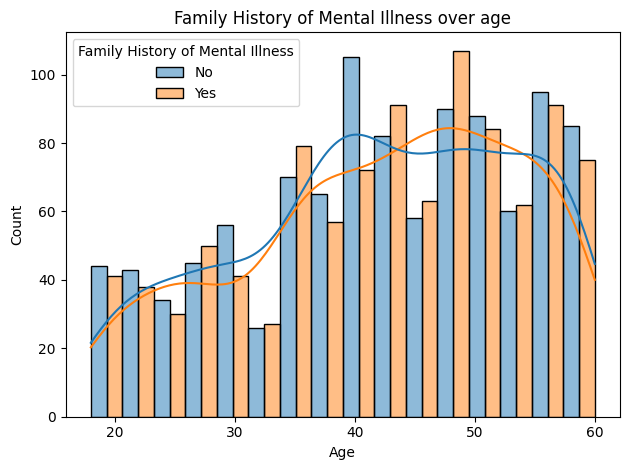

In [ ]:
sns.histplot(depression, x="Age", hue="Family History of Mental Illness", multiple="dodge", kde=True)
plt.title("Family History of Mental Illness over age")
plt.tight_layout()
plt.show()

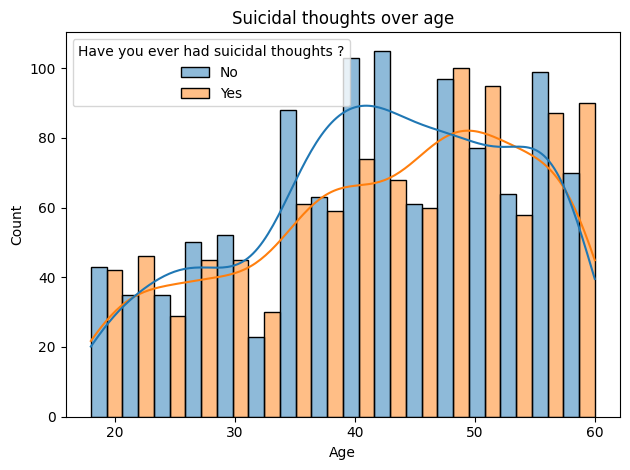

In [ ]:
sns.histplot(depression, x = "Age", hue = "Have you ever had suicidal thoughts ?", multiple = "dodge", kde = True) #Kernel Density Estimate (KDE)
plt.title("Suicidal thoughts over age")
plt.tight_layout()
plt.show()

# Post Encoding Data visualisation

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Encoding all String values into numerical
le = LabelEncoder()
for cols in depression.columns:
    if depression[cols].dtype == 'object':
        depression[cols] = le.fit_transform(depression[cols])

depression.head()



,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,37,2,4,1,1,0,6,2,0,0
1,1,60,4,3,0,2,1,0,4,1,0
2,0,42,2,3,0,1,0,0,2,0,0
3,0,44,3,5,1,0,1,1,2,1,0
4,1,48,4,3,1,1,1,6,5,1,0


In [ ]:
# Reload the original dataset to apply LabelEncoder again and capture mappings
temp_depression = pd.read_csv('Depression Professional Dataset.csv')

print('Mapping of encoded values to original categorical values for LabelEncoded columns:')

# Dictionary to store LabelEncoders for each column (or a custom mapping for 'Sleep Duration')
label_encoders = {}

# Define custom order for 'Sleep Duration'
sleep_duration_order = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours']

for col in temp_depression.columns:
    if temp_depression[col].dtype == 'object':
        if col == 'Sleep Duration':
            # Convert to categorical with desired order
            temp_depression[col] = pd.Categorical(temp_depression[col], categories=sleep_duration_order, ordered=True)
            # Get numerical codes based on the order of categories
            temp_depression[col] = temp_depression[col].cat.codes
            # Store the desired order for printing the mapping
            label_encoders[col] = {'classes_': sleep_duration_order}
        else:
            le = LabelEncoder()
            # Fit and transform the column, then store the encoder
            temp_depression[col] = le.fit_transform(temp_depression[col])
            label_encoders[col] = le

        print(f"\nColumn: {col}")
        # Print the mapping
        if col == 'Sleep Duration':
            for i, class_name in enumerate(label_encoders[col]['classes_']):
                print(f"  {i} : {class_name}")
        else:
            for i, class_name in enumerate(label_encoders[col].classes_):
                print(f"  {i} : {class_name}")

Mapping of encoded values to original categorical values for LabelEncoded columns:

Column: Gender
  0 : Female
  1 : Male

Column: Sleep Duration
  0 : Less than 5 hours
  1 : 5-6 hours
  2 : 7-8 hours
  3 : More than 8 hours

Column: Dietary Habits
  0 : Healthy
  1 : Moderate
  2 : Unhealthy

Column: Have you ever had suicidal thoughts ?
  0 : No
  1 : Yes

Column: Family History of Mental Illness
  0 : No
  1 : Yes

Column: Depression
  0 : No
  1 : Yes


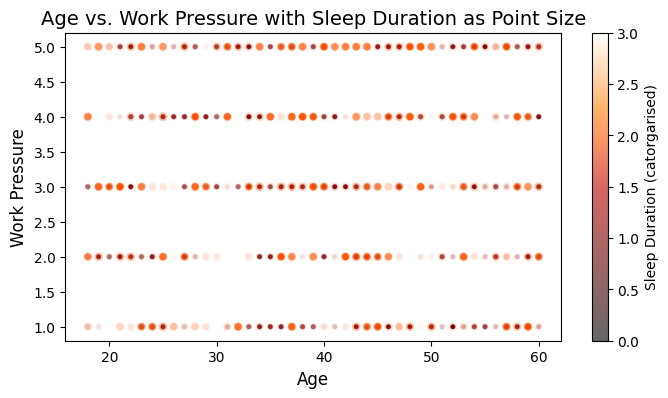

In [ ]:
data = {
    'Age': depression['Age'],
    'Work Pressure': depression['Work Pressure'],
    'Sleep Duration': depression['Sleep Duration']
}

df = pd.DataFrame(data)

# Create a scatter plot
plt.figure(figsize=(8, 4))

# Plotting Age vs. Work Pressure; using Sleep Duration to vary the size of the points
plt.scatter(df['Age'], df['Work Pressure'],
            s=df['Sleep Duration'] * 20,  # Adjust size by Sleep Duration (scaled)
            alpha=0.6,  # Make points slightly transparent
            c=df['Sleep Duration'],  # Color by Sleep Duration
            cmap='gist_heat',  # Colormap to red to black gradient
            edgecolors='w',
            label='Sleep Duration')

plt.title('Age vs. Work Pressure with Sleep Duration as Point Size', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Work Pressure', fontsize=12)

# color bar
plt.colorbar(label='Sleep Duration (catorgarised)')


plt.show()

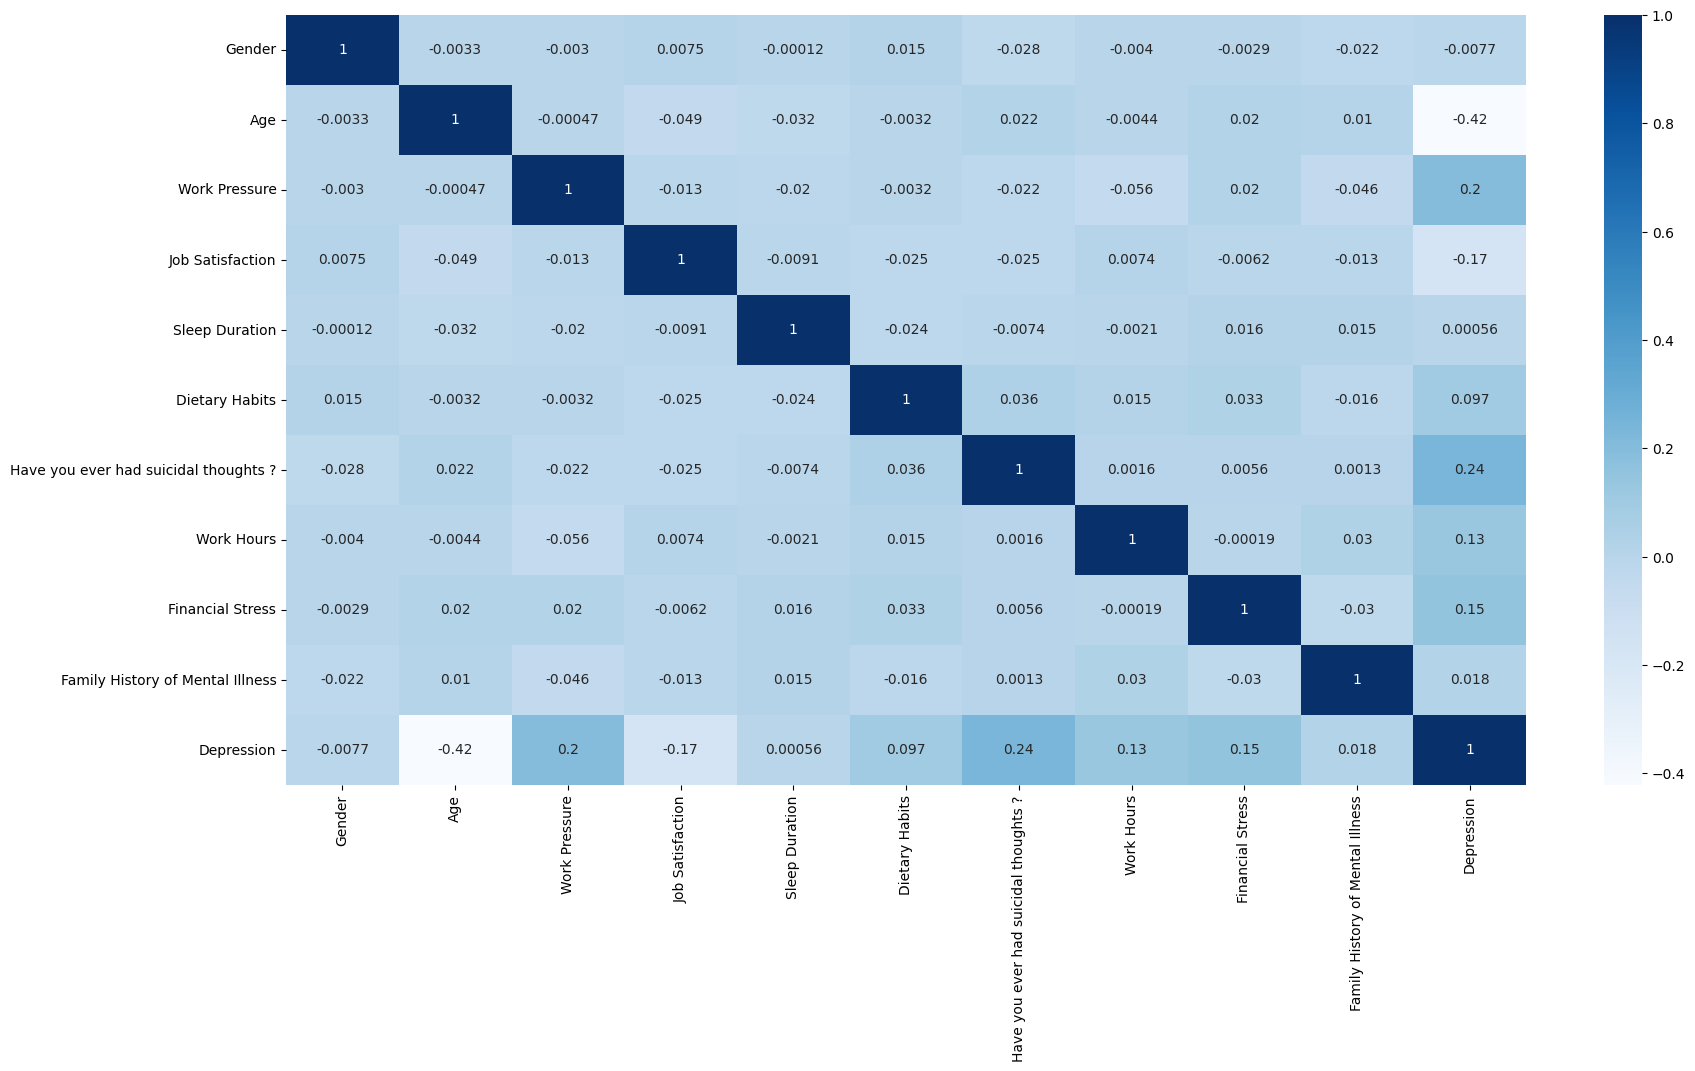

In [ ]:
#Correlation Matrix

plt.figure(figsize=(20,10))

sns.heatmap(depression.corr(), annot=True, cmap='Blues')
plt.show()

# Classification section

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV


In [ ]:
x = depression.drop('Depression', axis=1)
y = depression['Depression']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test= scaler.transform(x_test)

In [ ]:
DT = DecisionTreeClassifier(class_weight='balanced')

DT.fit(x_train, y_train)

y_pred = DT.predict(x_test)

accuracy_score(y_test, y_pred)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

dt_accuracy = accuracy_score(y_test, y_pred)
dt_f1_score = f1_score(y_test, y_pred)
dt_recall = recall_score(y_test, y_pred)
dt_precision = precision_score(y_test, y_pred)



[[361   7]
 [ 13  30]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       368
           1       0.81      0.70      0.75        43

    accuracy                           0.95       411
   macro avg       0.89      0.84      0.86       411
weighted avg       0.95      0.95      0.95       411



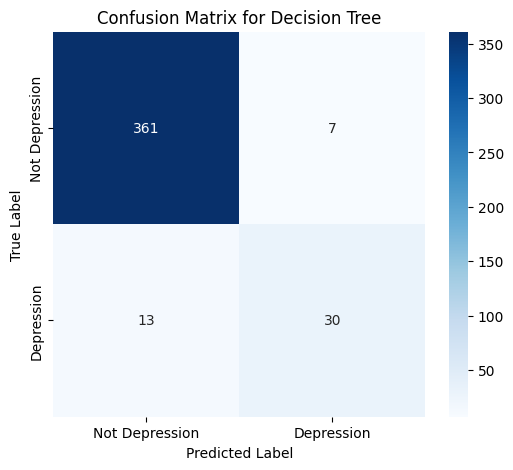

In [ ]:
# Get the confusion matrix for the tuned Logistic Regression model
cm = confusion_matrix(y_test, y_pred)

# Define class labels (e.g., 'No Depression', 'Depression')
class_labels = ['Not Depression', 'Depression']

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Decision Tree')
plt.show()

In [ ]:
rf = RandomForestClassifier(class_weight='balanced')

rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

accuracy_score(y_test, y_pred)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

rf_accuracy = accuracy_score(y_test, y_pred)
rf_f1_score = f1_score(y_test, y_pred)
rf_recall = recall_score(y_test, y_pred)
rf_precision = precision_score(y_test, y_pred)

[[368   0]
 [ 22  21]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       368
           1       1.00      0.49      0.66        43

    accuracy                           0.95       411
   macro avg       0.97      0.74      0.81       411
weighted avg       0.95      0.95      0.94       411



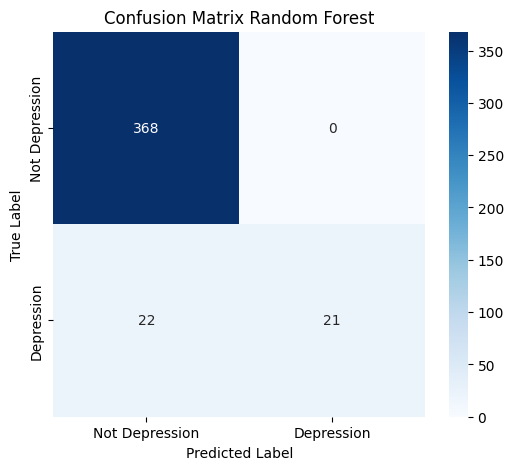

In [ ]:
# Get the confusion matrix for the tuned Logistic Regression model
cm = confusion_matrix(y_test, y_pred)

# Define class labels (e.g., 'No Depression', 'Depression')
class_labels = ['Not Depression', 'Depression']

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Random Forest')
plt.show()

In [ ]:
# Define the parameter grid for Decision Tree
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a GridSearchCV object
grid_search_dt = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=param_grid_dt, cv=5, scoring='accuracy')

# Fit the GridSearchCV object to the training data
grid_search_dt.fit(x_train, y_train)

# Print the best parameters and the best score
print("Best parameters for Decision Tree:", grid_search_dt.best_params_)
print("Best cross-validation accuracy for Decision Tree:", grid_search_dt.best_score_)

Best parameters for Decision Tree: {'criterion': 'gini', 'max_depth': 40, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best cross-validation accuracy for Decision Tree: 0.9452090592334494


In [ ]:
# Train a new Decision Tree model with the best parameters
best_dt_model = DecisionTreeClassifier(**grid_search_dt.best_params_, class_weight='balanced')
best_dt_model.fit(x_train, y_train)

# Predict on the test set
y_pred_tuned_dt = best_dt_model.predict(x_test)

# Evaluate the tuned model
print("Classification Report for Tuned Decision Tree:")
print(classification_report(y_test, y_pred_tuned_dt))

print("Confusion Matrix for Tuned Decision Tree:")
print(confusion_matrix(y_test, y_pred_tuned_dt))

# Store metrics for comparison
tuned_DT_accuracy = accuracy_score(y_test, y_pred_tuned_dt)
tuned_DT_precision = precision_score(y_test, y_pred_tuned_dt)
tuned_DT_recall = recall_score(y_test, y_pred_tuned_dt)
tuned_DT_f1_score = f1_score(y_test, y_pred_tuned_dt)

Classification Report for Tuned Decision Tree:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       368
           1       0.58      0.72      0.65        43

    accuracy                           0.92       411
   macro avg       0.78      0.83      0.80       411
weighted avg       0.93      0.92      0.92       411

Confusion Matrix for Tuned Decision Tree:
[[346  22]
 [ 12  31]]


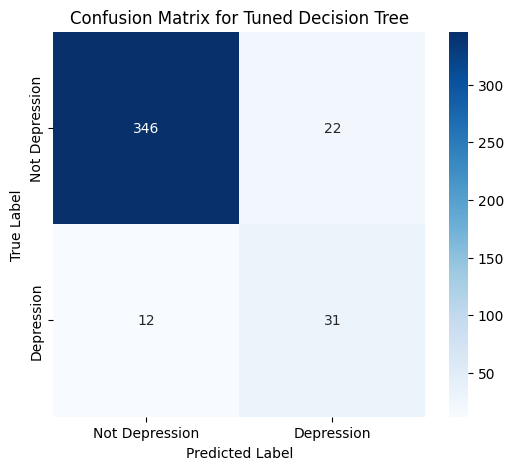

In [ ]:
# Get the confusion matrix for the tuned Logistic Regression model
cm = confusion_matrix(y_test, y_pred_tuned_dt)

# Define class labels (e.g., 'No Depression', 'Depression')
class_labels = ['Not Depression', 'Depression']

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned Decision Tree')
plt.show()

In [ ]:
# default K-Nearest model

KNN = KNeighborsClassifier()

KNN.fit(x_train, y_train)

y_pred = KNN.predict(x_test)

accuracy_score(y_test, y_pred)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

knn_accuracy = accuracy_score(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
knn_recall = recall_score(y_test, y_pred)
knn_precision = precision_score(y_test, y_pred)

[[367   1]
 [ 22  21]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       368
           1       0.95      0.49      0.65        43

    accuracy                           0.94       411
   macro avg       0.95      0.74      0.81       411
weighted avg       0.94      0.94      0.94       411



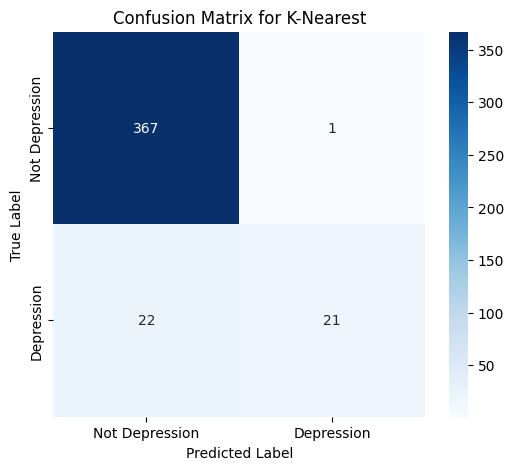

In [ ]:
# Get the confusion matrix for the tuned Logistic Regression model
cm = confusion_matrix(y_test, y_pred)

# Define class labels (e.g., 'No Depression', 'Depression')
class_labels = ['Not Depression', 'Depression']

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for K-Nearest')
plt.show()

In [ ]:
# defualt logistic regression model

LR = LogisticRegression(max_iter=10000, class_weight='balanced')

LR.fit(x_train, y_train)

y_pred = LR.predict(x_test)

accuracy_score(y_test, y_pred)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

LR_accuracy = accuracy_score(y_test, y_pred)
LR_f1_score = f1_score(y_test, y_pred)
LR_recall = recall_score(y_test, y_pred)
LR_precision = precision_score(y_test, y_pred)

[[358  10]
 [  0  43]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       368
           1       0.81      1.00      0.90        43

    accuracy                           0.98       411
   macro avg       0.91      0.99      0.94       411
weighted avg       0.98      0.98      0.98       411



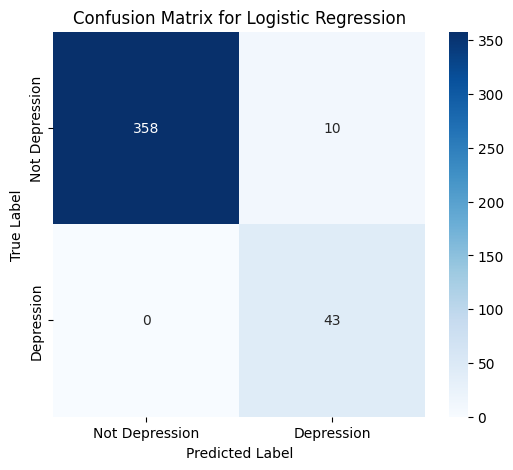

In [ ]:
# Get the confusion matrix for the tuned Logistic Regression model
cm = confusion_matrix(y_test, y_pred)

# Define class labels (e.g., 'No Depression', 'Depression')
class_labels = ['Not Depression', 'Depression']

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [ ]:
# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# Create a GridSearchCV object
grid_search_lr = GridSearchCV(estimator=LogisticRegression(max_iter=10000, random_state=42), # Increased max_iter for convergence
                            param_grid=param_grid_lr,
                            cv=5,
                            scoring='accuracy',
                            n_jobs=-1) # Use all available cores

# Fit the GridSearchCV object to the training data
grid_search_lr.fit(x_train, y_train)

# Print the best parameters and the best score
print("Best parameters for Logistic Regression:", grid_search_lr.best_params_)
print("Best cross-validation accuracy for Logistic Regression:", grid_search_lr.best_score_)

NameError: name 'GridSearchCV' is not defined

In [ ]:
# Train a new Logistic Regression model with the best parameters
best_lr_model = LogisticRegression(max_iter=10000, random_state=42, **grid_search_lr.best_params_, class_weight='balanced')
best_lr_model.fit(x_train, y_train)

# Predict on the test set
y_pred_tuned_lr = best_lr_model.predict(x_test)

# Evaluate the tuned model
print("\nClassification Report for Tuned Logistic Regression:")
print(classification_report(y_test, y_pred_tuned_lr))

print("\nConfusion Matrix for Tuned Logistic Regression:")
print(confusion_matrix(y_test, y_pred_tuned_lr))

print("\nAccuracy Score for Tuned Logistic Regression:", accuracy_score(y_test, y_pred_tuned_lr))

tuned_LR_accuracy = accuracy_score(y_test, y_pred_tuned_lr)
tuned_LR_f1_score = f1_score(y_test, y_pred_tuned_lr)
tuned_LR_recall = recall_score(y_test, y_pred_tuned_lr)
tuned_LR_precision = precision_score(y_test, y_pred_tuned_lr)


Classification Report for Tuned Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       368
           1       0.81      0.98      0.88        43

    accuracy                           0.97       411
   macro avg       0.90      0.97      0.93       411
weighted avg       0.98      0.97      0.97       411


Confusion Matrix for Tuned Logistic Regression:
[[358  10]
 [  1  42]]

Accuracy Score for Tuned Logistic Regression: 0.9732360097323601


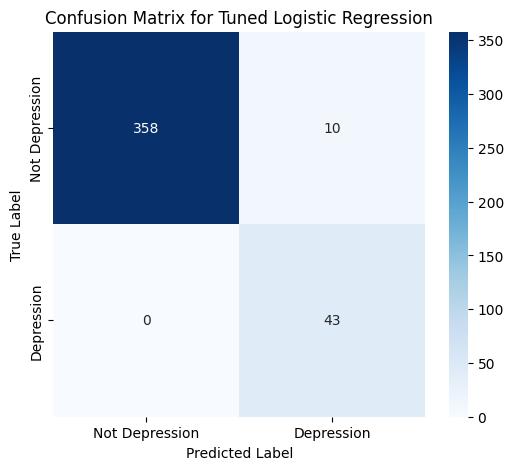

In [ ]:
# Get the confusion matrix for the tuned Logistic Regression model
cm = confusion_matrix(y_test, y_pred)

# Define class labels (e.g., 'No Depression', 'Depression')
class_labels = ['Not Depression', 'Depression']

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned Logistic Regression')
plt.show()

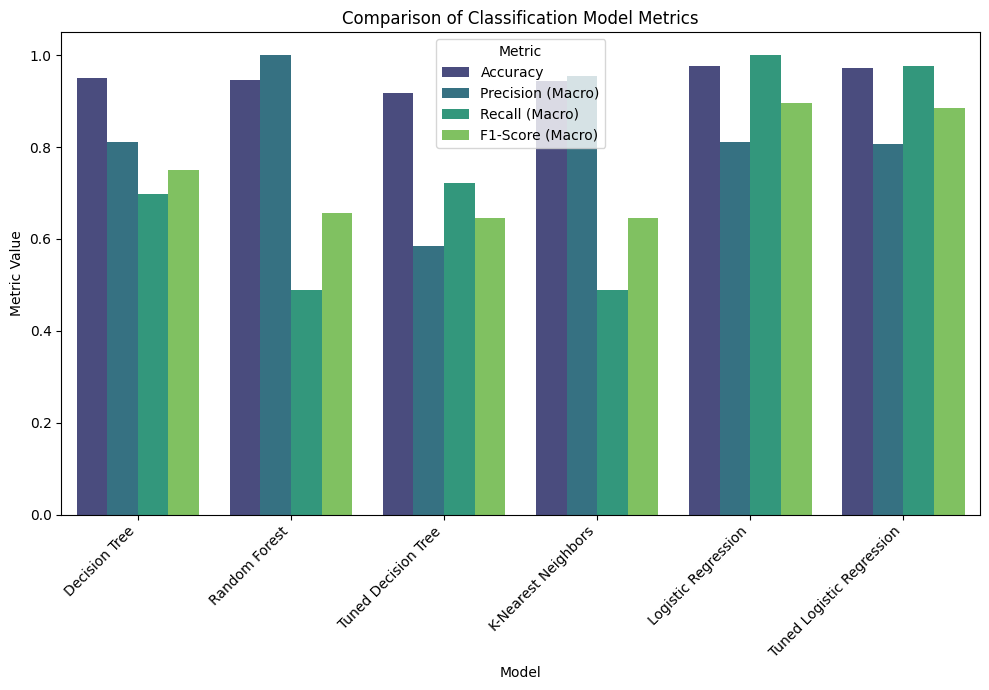

In [ ]:
# Metrics extracted from previous cell outputs
metrics_data = {
    'Model': ['Decision Tree', 'Random Forest', 'Tuned Decision Tree', 'K-Nearest Neighbors', 'Logistic Regression', 'Tuned Logistic Regression'],
    'Accuracy': [dt_accuracy, rf_accuracy, tuned_DT_accuracy, knn_accuracy, LR_accuracy, tuned_LR_accuracy],
    'Precision (Macro)': [dt_precision, rf_precision, tuned_DT_precision, knn_precision, LR_precision, tuned_LR_precision],
    'Recall (Macro)': [dt_recall, rf_recall, tuned_DT_recall, knn_recall, LR_recall, tuned_LR_recall],
    'F1-Score (Macro)': [dt_f1_score, rf_f1_score, tuned_DT_f1_score, knn_f1_score, LR_f1_score, tuned_LR_f1_score]
}

df_metrics = pd.DataFrame(metrics_data)

# Melt the DataFrame to long format for easier plotting
df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Value')

# Create the bar plot
plt.figure(figsize=(10, 7))
sns.barplot(x='Model', y='Value', hue='Metric', data=df_melted, palette='viridis')

plt.title('Comparison of Classification Model Metrics')
plt.ylabel('Metric Value')
plt.xlabel('Model')
plt.ylim(0, 1.05) # Metrics are typically between 0 and 1
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

# Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

from sklearn import tree


In [ ]:
x = depression.drop('Age', axis=1)
y = depression['Age']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# initialize the Naive Bayes classifier
LR = LinearRegression()

#fit the classifier to the data
LR.fit(x_train,y_train)

#use the resulting model to predict value on the test sey
y_pred = LR.predict(x_test)

print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_pred)), '\n')

print("R2 score:", r2_score(y_test, y_pred))

# Evaluating the model using Adjusted R² Evaluation Metric
adj_r2 = 1 - (1-r2_score(y_test, y_pred))*(len(y_pred)-1)/(len(y_pred)-x_test.shape[1]-1)
print("Adjusted R2 score:", adj_r2)

Mean Absolute Error: 8.318267339367466
Mean Squared Error: 101.17400413688972
Root Mean Squared Error: 10.058528925090872 

R2 score: 0.25292105805814413
Adjusted R2 score: 0.23424408450959777


In [ ]:
# Display the coefficients, t-test and p values
X2 = sm.add_constant(x)
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                    Age   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     62.36
Date:                Sun, 23 Nov 2025   Prob (F-statistic):          9.18e-111
Time:                        21:01:30   Log-Likelihood:                -7650.1
No. Observations:                2054   AIC:                         1.532e+04
Df Residuals:                    2043   BIC:                         1.538e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

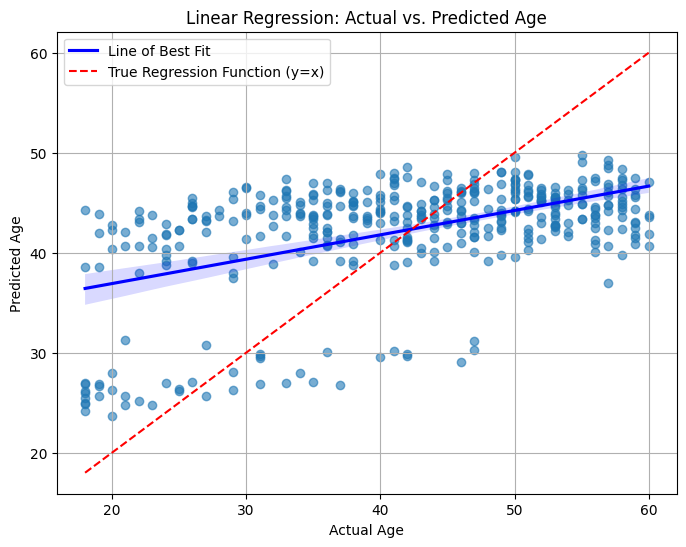

In [ ]:
plt.figure(figsize=(8, 6))

# Scatter plot of actual vs. predicted values
plt.scatter(y_test, y_pred, alpha=0.6)

# Add the line of best fit (regression line)
sns.regplot(x=y_test, y=y_pred, scatter=False, color='blue', label='Line of Best Fit')

# Add the true regression function line (y = x, representing perfect prediction)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='True Regression Function (y=x)')

plt.title('Linear Regression: Actual vs. Predicted Age')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Fit regression model
regr_1 = DecisionTreeRegressor(max_depth=2)
regr_2 = DecisionTreeRegressor(max_depth=5)
regr_1.fit(x_train,y_train)
regr_2.fit(x_train,y_train)

# Predict
y1_pred = regr_1.predict(x_test)
y2_pred = regr_2.predict(x_test)

print('Mean Absolute Error:', mean_absolute_error(y_test, y2_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y2_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y2_pred)), '\n')

print("R2 score:", r2_score(y_test, y2_pred))

# Evaluating the model using Adjusted R² Evaluation Metric
adj_r2 = 1 - (1-r2_score(y_test, y2_pred))*(len(y2_pred)-1)/(len(y2_pred)-x_test.shape[1]-1)
print("Adjusted R2 score:", adj_r2)

Mean Absolute Error: 8.681720331905165
Mean Squared Error: 110.11647386209356
Root Mean Squared Error: 10.49363968611909 

R2 score: 0.18688896930525423
Adjusted R2 score: 0.16656119353788557


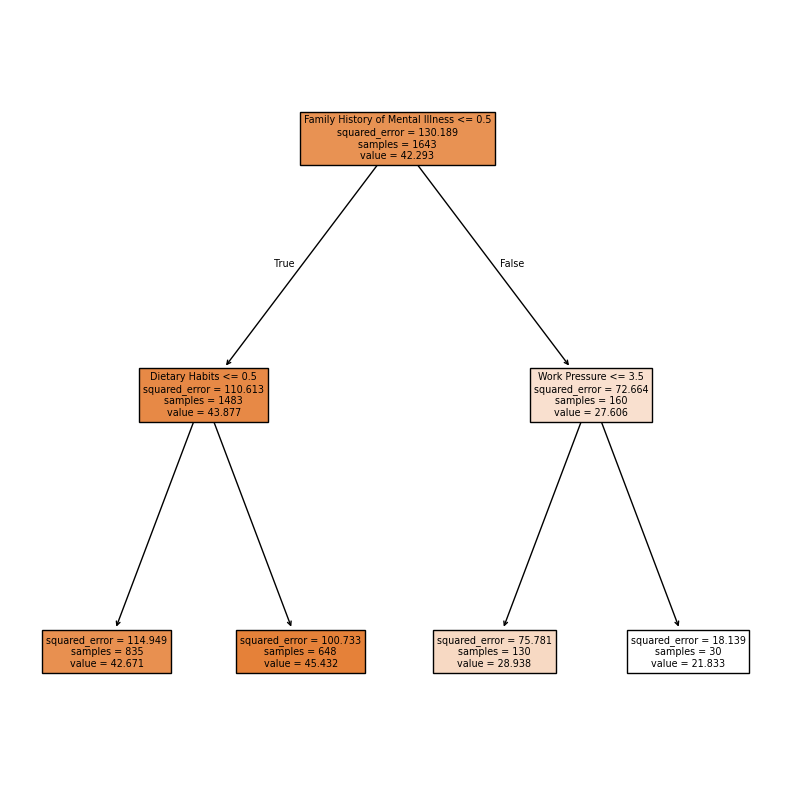

In [ ]:

plt.figure(figsize=(10, 10))
features = depression.columns
classes = ['<=50k','>50k']
tree.plot_tree(regr_1,feature_names=features,class_names=classes,filled=True)
plt.show()

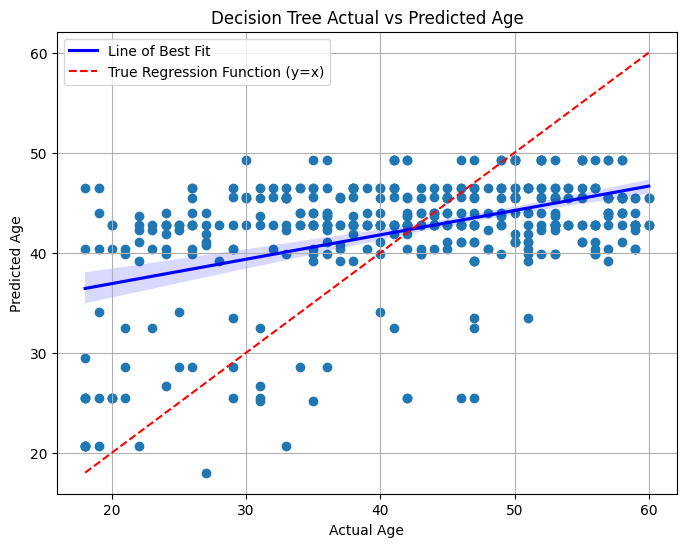

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y2_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

# Add the line of best fit (regression line)
sns.regplot(x=y_test, y=y_pred, scatter=False, color='blue', label='Line of Best Fit')

# Add the true regression function line (y = x, representing perfect prediction)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='True Regression Function (y=x)')

plt.title('Decision Tree Actual vs Predicted Age')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.legend()
plt.grid(True)
plt.show()

# Rule Mining


In [ ]:
pip install apyori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=1aba515ed9742d6346c918ebcf2fef7500480ab0cf55e39a2c3ff50b3182d168
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


In [ ]:
from apyori import apriori

In [ ]:
depression_1 = pd.read_csv('Depression Professional Dataset.csv')
depression_1.head()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,37,2,4,7-8 hours,Moderate,No,6,2,No,No
1,Male,60,4,3,5-6 hours,Unhealthy,Yes,0,4,Yes,No
2,Female,42,2,3,5-6 hours,Moderate,No,0,2,No,No
3,Female,44,3,5,7-8 hours,Healthy,Yes,1,2,Yes,No
4,Male,48,4,3,7-8 hours,Moderate,Yes,6,5,Yes,No


In [ ]:
depression_1.shape

(2054, 11)

In [ ]:
#transform numerical attributes into categorical ones
depression_1['Age'] = pd.qcut(depression_1['Age'], q=4)
depression_1['Age'].value_counts(sort=False)

,count
Age,
"(17.999, 35.0]",568
"(35.0, 43.0]",477
"(43.0, 51.75]",495
"(51.75, 60.0]",514


In [ ]:
#transform numerical attributes into categorical ones
depression_1['Work Pressure'] = pd.qcut(depression_1['Work Pressure'], q=4)
depression_1['Work Pressure'].value_counts(sort=False)

,count
Work Pressure,
"(0.999, 2.0]",814
"(2.0, 3.0]",404
"(3.0, 4.0]",412
"(4.0, 5.0]",424


In [ ]:
#transform numerical attributes into categorical ones
depression_1['Job Satisfaction'] = pd.qcut(depression_1['Job Satisfaction'], q=4)
depression_1['Job Satisfaction'].value_counts(sort=False)

,count
Job Satisfaction,
"(0.999, 2.0]",827
"(2.0, 3.0]",404
"(3.0, 4.0]",392
"(4.0, 5.0]",431


In [ ]:
#transform numerical attributes into categorical ones
depression_1['Work Hours'] = pd.qcut(depression_1['Work Hours'], q=4)
depression_1['Work Hours'].value_counts(sort=False)

,count
Work Hours,
"(-0.001, 3.0]",656
"(3.0, 6.0]",467
"(6.0, 9.0]",457
"(9.0, 12.0]",474


In [ ]:
#transform numerical attributes into categorical ones
depression_1['Financial Stress'] = pd.qcut(depression_1['Financial Stress'], q=4)
depression_1['Financial Stress'].value_counts(sort=False)

,count
Financial Stress,
"(0.999, 2.0]",854
"(2.0, 3.0]",388
"(3.0, 4.0]",407
"(4.0, 5.0]",405


In [ ]:
depression_1.shape

(2054, 11)

In [ ]:
data_list = []
for row in range(0, 2054):
    data_list.append([f"{depression_1.columns[column]}={str(depression_1.values[row,column])}" for column in range(0, 11)])

rules = apriori(data_list, min_support=0.05, min_confidence=0.5, min_length=2)
results = list(rules)

In [ ]:
#Put the results into a dataframe to have the rules listed in a table
df = pd.DataFrame(columns=('Items','Antecedent','Consequent','Support','Confidence','Lift'))

Support =[]
Confidence = []
Lift = []
Items = []
Antecedent = []
Consequent=[]

for RelationRecord in results:
    for ordered_stat in RelationRecord.ordered_statistics:
        Support.append(RelationRecord.support)
        Items.append(RelationRecord.items)
        Antecedent.append(ordered_stat.items_base)
        Consequent.append(ordered_stat.items_add)
        Confidence.append(ordered_stat.confidence)
        Lift.append(ordered_stat.lift)

df['Items'] = list(map(set, Items))
df['Antecedent'] = list(map(set, Antecedent))
df['Consequent'] = list(map(set, Consequent))
df['Support'] = Support
df['Confidence'] = Confidence
df['Lift']= Lift

#Sort resulted dataframe by Lift
df.sort_values(by ='Lift', ascending = False, inplace = True)

In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
df.shape

(2053, 6)

In [ ]:
above_1 = df[df["Lift"] > 1]

above_1.shape

(1633, 6)

In [ ]:
above_1

,Items,Antecedent,Consequent,Support,Confidence,Lift
0,"{Have you ever had suicidal thoughts ?=Yes, Ag...",{Depression=Yes},"{Have you ever had suicidal thoughts ?=Yes, Ag...",0.063778,0.645320,4.802492
1,"{Age=(17.999, 35.0], Depression=Yes}",{Depression=Yes},"{Age=(17.999, 35.0]}",0.078870,0.798030,2.885832
2,"{Have you ever had suicidal thoughts ?=Yes, Ag...","{Have you ever had suicidal thoughts ?=Yes, De...","{Age=(17.999, 35.0]}",0.063778,0.766082,2.770303
3,"{Job Satisfaction=(0.999, 2.0], Have you ever ...",{Depression=Yes},"{Job Satisfaction=(0.999, 2.0], Have you ever ...",0.053554,0.541872,2.761799
4,"{Have you ever had suicidal thoughts ?=Yes, De...",{Depression=Yes},{Have you ever had suicidal thoughts ?=Yes},0.083252,0.842365,1.749461
...,...,...,...,...,...,...
1628,"{Financial Stress=(4.0, 5.0], Have you ever ha...","{Financial Stress=(4.0, 5.0], Have you ever ha...",{Gender=Male},0.052580,0.519231,1.000469
1629,"{Sleep Duration=Less than 5 hours, Have you ev...","{Sleep Duration=Less than 5 hours, Have you ev...",{Family History of Mental Illness=No},0.065725,0.509434,1.000361
1630,"{Gender=Male, Have you ever had suicidal thoug...","{Have you ever had suicidal thoughts ?=Yes, Di...",{Gender=Male},0.066212,0.519084,1.000186
1631,"{Family History of Mental Illness=Yes, Dietary...","{Family History of Mental Illness=Yes, Dietary...",{Depression=No},0.066699,0.901316,1.000163


In [ ]:
# Remove mirrored rules
filtered_above_1 = pd.DataFrame(columns=('Items','Antecedent','Consequent','Support','Confidence','Lift'))
seen_items = set()

for index, row in above_1.iterrows():
    # Create a canonical representation of the item sets to identify mirrored rules
    item_set = frozenset(row['Items'])

    if item_set not in seen_items:
        filtered_above_1 = pd.concat([filtered_above_1, row.to_frame().T], ignore_index=True)
        seen_items.add(item_set)

# Display the filtered DataFrame
display(filtered_above_1)

,Items,Antecedent,Consequent,Support,Confidence,Lift
0,"{Have you ever had suicidal thoughts ?=Yes, Ag...",{Depression=Yes},"{Have you ever had suicidal thoughts ?=Yes, Ag...",0.063778,0.64532,4.802492
1,"{Age=(17.999, 35.0], Depression=Yes}",{Depression=Yes},"{Age=(17.999, 35.0]}",0.07887,0.79803,2.885832
2,"{Job Satisfaction=(0.999, 2.0], Have you ever ...",{Depression=Yes},"{Job Satisfaction=(0.999, 2.0], Have you ever ...",0.053554,0.541872,2.761799
3,"{Have you ever had suicidal thoughts ?=Yes, De...",{Depression=Yes},{Have you ever had suicidal thoughts ?=Yes},0.083252,0.842365,1.749461
4,"{Job Satisfaction=(0.999, 2.0], Depression=Yes}",{Depression=Yes},"{Job Satisfaction=(0.999, 2.0]}",0.063778,0.64532,1.602766
...,...,...,...,...,...,...
946,"{Have you ever had suicidal thoughts ?=No, Wor...","{Work Pressure=(4.0, 5.0]}",{Have you ever had suicidal thoughts ?=No},0.107108,0.518868,1.000709
947,"{Financial Stress=(4.0, 5.0], Have you ever ha...","{Financial Stress=(4.0, 5.0], Have you ever ha...",{Gender=Male},0.05258,0.519231,1.000469
948,"{Sleep Duration=Less than 5 hours, Have you ev...","{Sleep Duration=Less than 5 hours, Have you ev...",{Family History of Mental Illness=No},0.065725,0.509434,1.000361
949,"{Gender=Male, Have you ever had suicidal thoug...","{Have you ever had suicidal thoughts ?=Yes, Di...",{Gender=Male},0.066212,0.519084,1.000186


#CLustering

In [ ]:
!pip install kprototypes
!pip install hdbscan gower

In [ ]:
!pip install kmodes

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA

from kmodes.kprototypes import KPrototypes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import hdbscan
import gower

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [ ]:
depression = pd.read_csv('Depression Professional Dataset.csv')
depression.head()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,37,2,4,7-8 hours,Moderate,No,6,2,No,No
1,Male,60,4,3,5-6 hours,Unhealthy,Yes,0,4,Yes,No
2,Female,42,2,3,5-6 hours,Moderate,No,0,2,No,No
3,Female,44,3,5,7-8 hours,Healthy,Yes,1,2,Yes,No
4,Male,48,4,3,7-8 hours,Moderate,Yes,6,5,Yes,No


In [ ]:
# Encoding all String values into numerical
le = LabelEncoder()
for cols in depression.columns:
    if depression[cols].dtype == 'object':
        depression[cols] = le.fit_transform(depression[cols])

depression.head()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,37,2,4,1,1,0,6,2,0,0
1,1,60,4,3,0,2,1,0,4,1,0
2,0,42,2,3,0,1,0,0,2,0,0
3,0,44,3,5,1,0,1,1,2,1,0
4,1,48,4,3,1,1,1,6,5,1,0


In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(depression.values)
scaled_features_depression = pd.DataFrame(scaled_features, index=depression.index, columns=depression.columns)
scaled_features_depression.describe()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
count,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03,2.054000e+03
mean,2.248553e-17,-1.055090e-16,1.176166e-16,-8.475315e-17,-2.075587e-17,-7.956418e-17,-6.659176e-17,-4.151175e-17,1.245352e-16,2.248553e-17,8.648281e-18
std,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00,1.000244e+00
min,-1.038724e+00,-2.109530e+00,-1.426927e+00,-1.420994e+00,-1.348198e+00,-1.232992e+00,-9.636589e-01,-1.571912e+00,-1.400250e+00,-9.816675e-01,-3.311653e-01
25%,-1.038724e+00,-6.259035e-01,-7.211941e-01,-7.158184e-01,-4.438221e-01,-1.232992e+00,-9.636589e-01,-7.767947e-01,-6.925449e-01,-9.816675e-01,-3.311653e-01
50%,9.627197e-01,7.227356e-02,-1.546152e-02,-1.064286e-02,-4.438221e-01,-1.891455e-02,-9.636589e-01,1.832306e-02,1.516019e-02,-9.816675e-01,-3.311653e-01
75%,9.627197e-01,8.359047e-01,6.902710e-01,6.945326e-01,4.605535e-01,1.195163e+00,1.037712e+00,8.134408e-01,7.228652e-01,1.018675e+00,-3.311653e-01
max,9.627197e-01,1.555900e+00,1.396004e+00,1.399708e+00,1.364929e+00,1.195163e+00,1.037712e+00,1.608558e+00,1.430570e+00,1.018675e+00,3.019640e+00


# K-Prototypes

In [ ]:
df = pd.read_csv("Depression Professional Dataset.csv")

categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].astype(str)

data_matrix = df.to_numpy()
categorical_idx = [df.columns.get_loc(c) for c in categorical_cols]

kproto = KPrototypes(n_clusters=2, init='Huang', random_state=42)
clusters = kproto.fit_predict(data_matrix, categorical=categorical_idx)

df["cluster"] = clusters
print(df.head())


   Gender  Age  Work Pressure  Job Satisfaction Sleep Duration Dietary Habits  \
0  Female   37              2                 4      7-8 hours       Moderate   
1    Male   60              4                 3      5-6 hours      Unhealthy   
2  Female   42              2                 3      5-6 hours       Moderate   
3  Female   44              3                 5      7-8 hours        Healthy   
4    Male   48              4                 3      7-8 hours       Moderate   

  Have you ever had suicidal thoughts ?  Work Hours  Financial Stress  \
0                                    No           6                 2   
1                                   Yes           0                 4   
2                                    No           0                 2   
3                                   Yes           1                 2   
4                                   Yes           6                 5   

  Family History of Mental Illness Depression  cluster  
0                

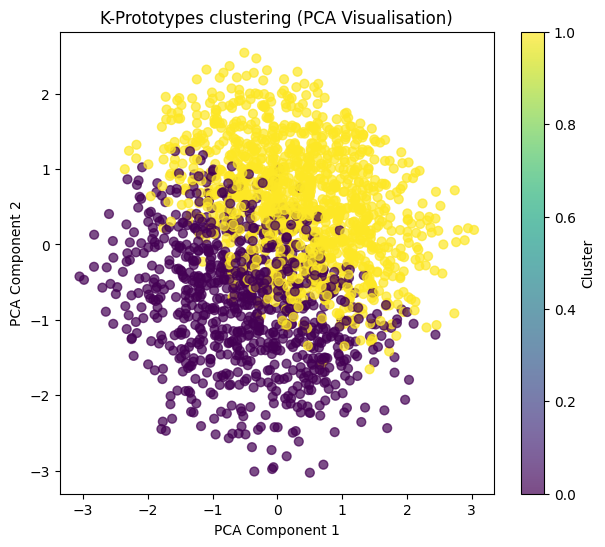

In [ ]:
# Load dataset
df = pd.read_csv("Depression Professional Dataset.csv")

# Identify categorical and numeric columns
categorical_cols = df.select_dtypes(include=['object']).columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Convert categoricals to string
df[categorical_cols] = df[categorical_cols].astype(str)

# Prepare data for K-Prototypes
data_matrix = df.to_numpy()
categorical_idx = [df.columns.get_loc(c) for c in categorical_cols]

# Fit K-Prototypes
kproto = KPrototypes(n_clusters=2, init='Huang', random_state=42)
clusters = kproto.fit_predict(data_matrix, categorical=categorical_idx)

# Attach clusters to dataframe
df["cluster"] = clusters


# VISUALIZATION


# One-hot encode categoricals for visualization
enc = OneHotEncoder(sparse_output=False)
cat_encoded = enc.fit_transform(df[categorical_cols])

# Scale numerics
scaler = StandardScaler()
num_scaled = scaler.fit_transform(df[numeric_cols])

# Combine encoded data
visual_matrix = np.hstack([num_scaled, cat_encoded])

# Reduce to 2D with PCA
pca = PCA(n_components=2)
components = pca.fit_transform(visual_matrix)

# Plot clusters
plt.figure(figsize=(7,6))
plt.scatter(components[:,0], components[:,1],
            c=df["cluster"], s=40, alpha=0.7)

plt.title("K-Prototypes clustering (PCA Visualisation)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()


In [ ]:
# Davies-Bouldin Index


db_index_kproto = davies_bouldin_score(visual_matrix, df["cluster"])

print(f"Davies-Bouldin Index (K-Prototypes): {db_index_kproto:.2f}")


Davies-Bouldin Index (K-Prototypes): 3.11


#HDBSCAN

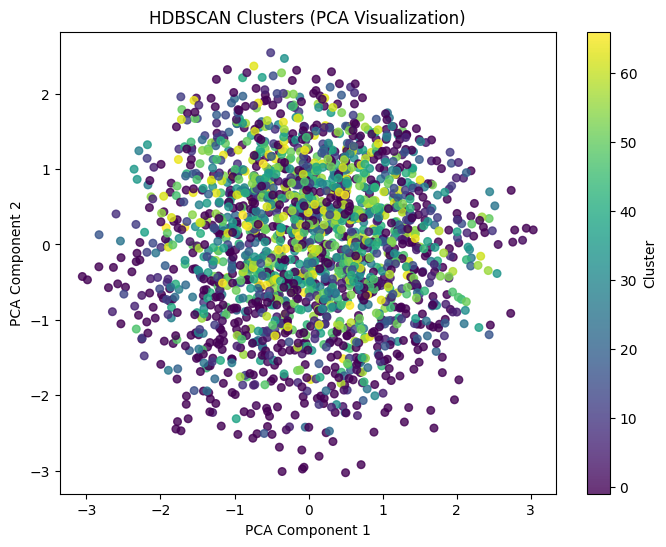

In [ ]:

# Load data
df = pd.read_csv("Depression Professional Dataset.csv")

# Identify column types
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include='number').columns

# Convert categoricals to strings
df[cat_cols] = df[cat_cols].astype(str)

gower_dist = gower.gower_matrix(df)

# Fix: Convert gower_dist to float64 to prevent dtype mismatch with hdbscan
gower_dist = gower_dist.astype(np.float64)

clusterer = hdbscan.HDBSCAN(
    metric='precomputed',
    min_cluster_size=10,
    min_samples=5,
    cluster_selection_method='leaf'
)

labels = clusterer.fit_predict(gower_dist)

df["cluster"] = labels

enc = OneHotEncoder(sparse_output=False)
cat_encoded = enc.fit_transform(df[cat_cols])

# Scale numeric features
scaler = StandardScaler()
num_scaled = scaler.fit_transform(df[num_cols])

# Combine encoded data
visual_matrix = np.hstack([num_scaled, cat_encoded])

pca = PCA(n_components=2)
components = pca.fit_transform(visual_matrix)


plt.figure(figsize=(8, 6))
plt.scatter(
    components[:,0], components[:,1],
    c=df["cluster"],
    s=30,
    cmap="viridis",
    alpha=0.8
)

plt.title("HDBSCAN Clusters (PCA Visualization)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()


In [ ]:
# Filter out noise
non_noise_indices = labels != -1
filtered_scaled_features = scaled_features_depression[non_noise_indices]
filtered_labels = labels[non_noise_indices]

if len(np.unique(filtered_labels)) >= 2:
   db_index = davies_bouldin_score(filtered_scaled_features, filtered_labels)
   print(f"Davies-Bouldin Index (HDBSCAN, excluding noise): {db_index:.2f}")
else:
   print("Cannot calculate Davies-Bouldin Index: Less than 2 clusters found after filtering noise.")

Davies-Bouldin Index (HDBSCAN, excluding noise): 7.01
